# Analiza Głównych Składowych (PCA)

**Cel:** Redukcja wymiarowości danych (usunięcie szumu i redundancji) przy jednoczesnym zachowaniu jak największej ilości informacji o spółkach.

### Krok 1: Wczytanie i ostateczne czyszczenie danych
Wczytujemy nasz przygotowany plik `aggregated_company_data.csv`. Ponieważ PCA operuje wyłącznie na liczbach i nie toleruje braków danych (NaN), stosujemy imputację: puste wartości wypełniamy zerem, co w przypadku naszych **ustandaryzowanych danych** oznacza po prostu przypisanie danej spółce rynkowej średniej. Usuwamy również z analizy kolumny kategoryczne/identyfikatory.

In [86]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns

LOCAL_FOLDER = Path.cwd().parent / "local_folder"
df_pca = pd.read_csv(LOCAL_FOLDER / 'aggregated_company_data.csv')

df_pca = df_pca.replace([np.inf, -np.inf], np.nan)
df_pca = df_pca.fillna(0)

# --- NOWA LOGIKA WYBORU KOLUMN ---

# 1. Definiujemy sztywną listę konkretnych metryk
explicit_columns = [
    'PriceToSales', 
    'NetIncome', 
    'PriceToEarnings', 
    'EarningsYield',
    'Risk-AdjustedGrowth', 
    'Earnings-to-Growth', 
    'ESG_Signal-to-Noise'
]

# 2. Automatycznie wyszukujemy wszystkie kolumny, których nazwa kończy się na "_cv"
cv_columns = [col for col in df_pca.columns if str(col).endswith('_cv') and not str(col) == 'ProfitMargin_cv' and not str(col) == 'ESG_Signal-to-Noise']

# 3. Łączymy obie listy w jeden ostateczny zbiór
columns_to_keep = cv_columns + explicit_columns

# 4. Zabezpieczenie (opcjonalne, ale bardzo polecane w dobrym kodzie): 
# Wybieramy z naszej listy tylko te kolumny, które faktycznie istnieją w tabeli.
# Zapobiega to błędom, gdyby np. ktoś zmienił nazwę kolumny we wcześniejszym pliku.
final_columns = [col for col in columns_to_keep if col in df_pca.columns]

# Wycinamy z oryginalnej tabeli tylko to, co nas interesuje
X = df_pca[final_columns]

# ---------------------------------

print(f"Dane gotowe do PCA. Liczba wierszy: {X.shape[0]}, Liczba analizowanych metryk: {X.shape[1]}")
display(X.head())

Dane gotowe do PCA. Liczba wierszy: 1000, Liczba analizowanych metryk: 11


,Revenue_cv,MarketCap_cv,GrowthRate_cv,ESG_Overall_cv,PriceToSales,NetIncome,PriceToEarnings,EarningsYield,Risk-AdjustedGrowth,Earnings-to-Growth,ESG_Signal-to-Noise
0,-0.6536,-0.6124,-0.0294,-0.4050,-1.0673,-0.3638,0.0554,0.8373,0.3717,-0.1196,0.7453
1,-0.0105,2.6964,-0.0169,-0.4050,-0.5501,-0.3890,-0.2908,-1.6436,-0.0867,-0.0069,0.7453
2,-0.0105,0.5342,-0.0351,-0.4050,-0.7137,-0.3636,0.0580,0.5272,0.9857,-0.1214,-0.3204
3,-0.8144,-1.0055,0.0003,0.1761,2.7428,0.4684,0.0687,-0.4031,-0.3078,-0.0875,0.9191
4,-1.2968,-0.8090,0.0346,-0.4050,0.2944,-0.0247,0.0555,0.8373,-0.4633,-0.0902,-1.1966


### Krok 2: Uruchomienie modelu i analiza wariancji (Ile informacji nam zostaje?)
Inicjujemy model PCA. W pierwszym kroku nie limitujemy liczby składowych (tworzymy ich tyle, ile mamy oryginalnych metryk), aby sprawdzić "Wariancję Wyjaśnioną" (*Explained Variance*). Ten wskaźnik procentowy powie nam, ile wiedzy o spółkach niesie w sobie każda kolejna składowa PC.

In [87]:
pca = PCA()
pca.fit(X)

explained_variance = pca.explained_variance_ratio_ * 100

cumulative_variance = np.cumsum(explained_variance)

pca_summary = pd.DataFrame({
    'Składowa': [f'PC{i+1}' for i in range(len(explained_variance))],
    'Wariancja (%)': explained_variance,
    'Skumulowana wariancja (%)': cumulative_variance
})

print("Tabela Wariancji Wyjaśnionej:")
display(pca_summary.round(2))

Tabela Wariancji Wyjaśnionej:


,Składowa,Wariancja (%),Skumulowana wariancja (%)
0,PC1,16.69,16.69
1,PC2,14.24,30.94
2,PC3,13.71,44.64
3,PC4,9.97,54.61
4,PC5,9.51,64.12
5,PC6,8.74,72.86
6,PC7,8.22,81.09
7,PC8,6.47,87.56
8,PC9,5.25,92.81
9,PC10,4.26,97.06


### Krok 3: Czym właściwie są moje składowe?
Skoro wiemy już, ile wymiarów potrzebujemy, musimy zrozumieć, co one z biznesowego punktu widzenia oznaczają. 

Tabela **Ładunków (Loadings)** pokazuje wpływ (od -1 do 1) oryginalnych metryk na nowe Składowe. Jeśli jakaś zmienna ma dużą wartość bezwzględną (np. 0.8 lub -0.7) w kolumnie PC1, oznacza to, że PC1 w dużej mierze reprezentuje właśnie tę oryginalną metrykę. Generujemy z tego Mapę Ciepła (Heatmap), aby od razu wyłapać te zależności.

#### W fuzzy_rules_27 zostały uzyte: `EarningsYield`, `Risk-AdjustedGrowth`, `ESG_Signal-to-Noise`

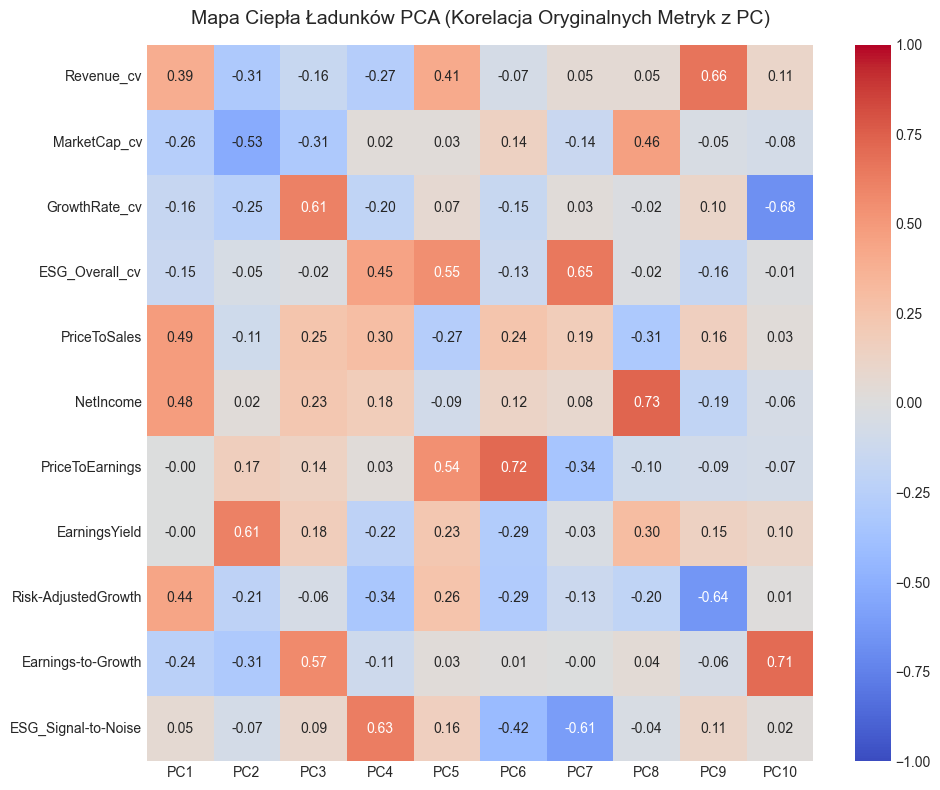

=== CO BUDUJE SKŁADOWĄ PC1? ===
PriceToSales           0.491706
NetIncome              0.480787
Risk-AdjustedGrowth    0.443014
Revenue_cv             0.392394
MarketCap_cv           0.264686
Name: PC1, dtype: float64

=== CO BUDUJE SKŁADOWĄ PC2? ===
EarningsYield         0.614442
MarketCap_cv          0.527459
Earnings-to-Growth    0.309483
Revenue_cv            0.306166
GrowthRate_cv         0.248487
Name: PC2, dtype: float64

=== CO BUDUJE SKŁADOWĄ PC3? ===
GrowthRate_cv         0.610864
Earnings-to-Growth    0.572808
MarketCap_cv          0.310317
PriceToSales          0.247846
NetIncome             0.231722
Name: PC3, dtype: float64

=== CO BUDUJE SKŁADOWĄ PC4? ===
ESG_Signal-to-Noise    0.626653
ESG_Overall_cv         0.448210
Risk-AdjustedGrowth    0.335816
PriceToSales           0.296849
Revenue_cv             0.270297
Name: PC4, dtype: float64

=== CO BUDUJE SKŁADOWĄ PC5? ===
ESG_Overall_cv         0.551635
PriceToEarnings        0.543356
Revenue_cv             0.412199
PriceT

In [88]:
num_components_to_analyze = 10

loadings = pd.DataFrame(
    pca.components_.T[:, :num_components_to_analyze], 
    columns=[f'PC{i+1}' for i in range(num_components_to_analyze)],
    index=X.columns
)

plt.figure(figsize=(10, 8))
sns.heatmap(loadings, annot=True, cmap='coolwarm', fmt=".2f", center=0, vmin=-1, vmax=1)
plt.title('Mapa Ciepła Ładunków PCA (Korelacja Oryginalnych Metryk z PC)', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

loadings = pd.DataFrame(
    pca.components_.T[:, :5],
    columns=['PC1', 'PC2', 'PC3', 'PC4', 'PC5'],
    index=X.columns
)

print("=== CO BUDUJE SKŁADOWĄ PC1? ===")
print(loadings['PC1'].abs().sort_values(ascending=False).head(5))

print("\n=== CO BUDUJE SKŁADOWĄ PC2? ===")
print(loadings['PC2'].abs().sort_values(ascending=False).head(5))

print("\n=== CO BUDUJE SKŁADOWĄ PC3? ===")
print(loadings['PC3'].abs().sort_values(ascending=False).head(5))

print("\n=== CO BUDUJE SKŁADOWĄ PC4? ===")
print(loadings['PC4'].abs().sort_values(ascending=False).head(5))

print("\n=== CO BUDUJE SKŁADOWĄ PC5? ===")
print(loadings['PC5'].abs().sort_values(ascending=False).head(5))